In [1]:
# 🚀 Load Data for Model Building
# Load meteorological data (X features) and 2D wave spectra (Y targets)

import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

print("🚀 Loading data for model building...")

# =============================================================================
# 📊 Load Meteorological DataFrames (X Features)
# =============================================================================

print("\n📊 Loading meteorological dataframes...")

# Define dataframes directory path
dataframes_dir = Path('../data/dataframes')

if not dataframes_dir.exists():
    print(f"❌ Directory not found: {dataframes_dir}")
    print("   Make sure to run the data engineering pipeline first!")
else:
    print(f"📁 Loading from: {dataframes_dir.absolute()}")
    
    # Find all met pickle files
    met_pkl_files = list(dataframes_dir.glob("met_*.pkl"))
    
    if not met_pkl_files:
        print("❌ No meteorological pickle files found!")
    else:
        print(f"🎯 Found {len(met_pkl_files)} meteorological files")
        
        # Load each met dataframe
        loaded_met_count = 0
        failed_met_count = 0
        met_size_mb = 0
        loaded_met_dfs = []
        
        for pkl_file in sorted(met_pkl_files):
            try:
                # Extract dataframe name from filename
                df_name = pkl_file.stem
                
                # Load dataframe from pickle
                df = pd.read_pickle(pkl_file)
                
                # Create variable in global namespace
                globals()[df_name] = df
                
                # Get file size
                file_size_mb = pkl_file.stat().st_size / (1024 * 1024)
                met_size_mb += file_size_mb
                
                loaded_met_count += 1
                loaded_met_dfs.append(df_name)
                
                print(f"  ✅ {df_name}: {df.shape} ({file_size_mb:.2f} MB)")
                
            except Exception as e:
                failed_met_count += 1
                print(f"  ❌ {pkl_file.name}: Error - {str(e)}")
        
        print(f"\n✅ Meteorological data loading completed!")
        print(f"   ✅ Successfully loaded: {loaded_met_count}")
        print(f"   ❌ Failed to load: {failed_met_count}")
        print(f"   💽 Total size: {met_size_mb:.2f} MB")

# =============================================================================
# 🌊 Load 2D Wave Spectrum Y DataFrames (Y Targets)
# =============================================================================

print("\n🌊 Loading 2D wave spectrum Y variables...")

# Check Y spectra directory
y_spectra_dir = Path('../data/Y_spectra')

if not y_spectra_dir.exists():
    print(f"❌ Y spectra directory not found: {y_spectra_dir}")
    print("   Run Y_prep.ipynb first to create 2D wave spectra!")
else:
    print(f"📁 Loading from: {y_spectra_dir.absolute()}")
    
    # Find all Y pickle files
    y_pkl_files = list(y_spectra_dir.glob("Y_*.pkl"))
    
    if not y_pkl_files:
        print("❌ No Y spectrum pickle files found!")
    else:
        print(f"🎯 Found {len(y_pkl_files)} Y spectrum files")
        
        # Load each Y variable
        loaded_y_count = 0
        failed_y_count = 0
        y_size_mb = 0
        loaded_y_dfs = []
        
        for pkl_file in sorted(y_pkl_files):
            try:
                # Extract variable name from filename
                y_name = pkl_file.stem  # Remove .pkl extension
                
                # Load DataFrame
                y_df = pd.read_pickle(pkl_file)
                
                # Store in global namespace
                globals()[y_name] = y_df
                
                # Get file size
                file_size_mb = pkl_file.stat().st_size / (1024 * 1024)
                y_size_mb += file_size_mb
                
                loaded_y_dfs.append(y_name)
                loaded_y_count += 1
                
                print(f"  ✅ {y_name}: {y_df.shape} ({file_size_mb:.2f} MB)")
                
            except Exception as e:
                failed_y_count += 1
                print(f"  ❌ {pkl_file.name}: Error - {str(e)}")
        
        print(f"\n✅ Y spectrum data loading completed!")
        print(f"   ✅ Successfully loaded: {loaded_y_count}")
        print(f"   ❌ Failed to load: {failed_y_count}")
        print(f"   💽 Total size: {y_size_mb:.2f} MB")

print("\n✅ All data loaded successfully! Ready for model building.")

🚀 Loading data for model building...

📊 Loading meteorological dataframes...
📁 Loading from: d:\projects\FYP-OCNWVS\notebooks\..\data\dataframes
🎯 Found 21 meteorological files
  ✅ met_41008_2006: (739, 7) (0.04 MB)
  ✅ met_41008_2007: (8650, 7) (0.50 MB)
  ✅ met_41008_2008: (8650, 7) (0.50 MB)
  ✅ met_41008_2009: (3250, 7) (0.19 MB)
  ✅ met_41008_2013: (8041, 7) (0.47 MB)
  ✅ met_41008_2014: (8406, 7) (0.49 MB)
  ✅ met_41008_2015: (8644, 7) (0.50 MB)
  ✅ met_41008_2016: (6151, 7) (0.36 MB)
  ✅ met_41008_2017: (8583, 7) (0.50 MB)
  ✅ met_41008_2018: (8613, 7) (0.50 MB)
  ✅ met_41008_2019: (8586, 7) (0.50 MB)
  ✅ met_41008_2020: (8580, 7) (0.50 MB)
  ✅ met_41008_2021: (8490, 7) (0.49 MB)
  ✅ met_41008_2022: (8655, 7) (0.50 MB)
  ✅ met_41008_2023: (5322, 7) (0.31 MB)
  ✅ met_41008_2024: (1825, 7) (0.11 MB)
  ✅ met_41008_2025: (1791, 7) (0.10 MB)
  ✅ met_51028_2005: (6787, 7) (0.40 MB)
  ✅ met_51028_2006: (7073, 7) (0.41 MB)
  ✅ met_51028_2007: (2962, 7) (0.17 MB)
  ✅ met_51028_2008: (250

In [2]:
# 🔧 Process X Features (Meteorological Data)
# Convert directional variables to sin/cos and standardize

from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("🔧 Processing X features (meteorological data)...")

# =============================================================================
# 🔄 Process All Meteorological DataFrames  
# =============================================================================

# Find all met variables
met_variables = [name for name in globals().keys() if name.startswith('met_') and isinstance(globals()[name], pd.DataFrame)]

if not met_variables:
    print("❌ No meteorological dataframes found!")
else:
    print(f"\n🎯 Processing {len(met_variables)} meteorological datasets...")
    
    # Storage for processed data
    X_processed = {}
    feature_names = None
    
    # Process all datasets (convert directions, handle missing) WITHOUT scaling
    print(f"\n📊 Converting directions and handling missing values...")
    
    for met_name in sorted(met_variables):
        print(f"  📍 Processing {met_name}...")
        
        met_df = globals()[met_name]
        
        # Create copy to avoid modifying original
        df = met_df.copy()
        
        # Remove timekey column
        if 'timekey' in df.columns:
            df = df.drop('timekey', axis=1)
        
        print(f"    Original columns: {list(df.columns)}")
        
        # Convert directional variables to sin/cos
        directional_cols = ['WDIR', 'MWD']  # Wind direction, Mean Wave Direction
        
        for col in directional_cols:
            if col in df.columns:
                # Convert degrees to radians
                angles_rad = np.deg2rad(df[col])
                
                # Create sin/cos components
                df[f'{col}_sin'] = np.sin(angles_rad)
                df[f'{col}_cos'] = np.cos(angles_rad)
                
                # Drop original angle column
                df = df.drop(col, axis=1)
                print(f"    ✅ Converted {col} → {col}_sin, {col}_cos")
        
        # Expected final columns: [WSPD, WVHT, DPD, APD, WDIR_sin, WDIR_cos, MWD_sin, MWD_cos]
        final_cols = list(df.columns)
        print(f"    Final columns ({len(final_cols)}): {final_cols}")
        
        # Get feature names (should be same for all datasets)
        if feature_names is None:
            feature_names = final_cols
        
        # Convert to numpy array (unscaled)
        X_unscaled = df.values
        
        # Store UNSCALED processed data
        X_processed[met_name] = X_unscaled
        
        print(f"    ✅ Processed shape: {X_unscaled.shape} (UNSCALED)")
    
    print(f"\n✅ Meteorological data processing completed!")
    print(f"   📊 Processed datasets: {len(X_processed)}")
    print(f"   🔧 Feature names: {feature_names}")
    print(f"   📏 Data is UNSCALED - scaling will be done after train-test split")
    
    # Show summary by station
    stations = {}
    for met_name in X_processed.keys():
        parts = met_name.split('_')
        if len(parts) >= 3:
            station = parts[1]
            year = parts[2]
            if station not in stations:
                stations[station] = []
            stations[station].append((year, X_processed[met_name].shape))
    
    print(f"\n📍 X Features by Station:")
    for station, data in sorted(stations.items()):
        years = [item[0] for item in data]
        total_samples = sum(item[1][0] for item in data)
        n_features = data[0][1][1] if data else 0
        print(f"   Station {station}: {len(data)} years ({', '.join(sorted(years))}) - {total_samples:,} samples × {n_features} features")

print(f"\n🎯 X features ready for alignment and train-test split!")
print(f"📋 Expected 8 features: [WSPD, WVHT, DPD, APD, WDIR_sin, WDIR_cos, MWD_sin, MWD_cos]")

print(f"\n🎯 X features ready for model training!")

🔧 Processing X features (meteorological data)...

🎯 Processing 21 meteorological datasets...

📊 Converting directions and handling missing values...
  📍 Processing met_41008_2006...
    Original columns: ['WDIR', 'WSPD', 'WVHT', 'DPD', 'APD', 'MWD']
    ✅ Converted WDIR → WDIR_sin, WDIR_cos
    ✅ Converted MWD → MWD_sin, MWD_cos
    Final columns (8): ['WSPD', 'WVHT', 'DPD', 'APD', 'WDIR_sin', 'WDIR_cos', 'MWD_sin', 'MWD_cos']
    ✅ Processed shape: (739, 8) (UNSCALED)
  📍 Processing met_41008_2007...
    Original columns: ['WDIR', 'WSPD', 'WVHT', 'DPD', 'APD', 'MWD']
    ✅ Converted WDIR → WDIR_sin, WDIR_cos
    ✅ Converted MWD → MWD_sin, MWD_cos
    Final columns (8): ['WSPD', 'WVHT', 'DPD', 'APD', 'WDIR_sin', 'WDIR_cos', 'MWD_sin', 'MWD_cos']
    ✅ Processed shape: (8650, 8) (UNSCALED)
  📍 Processing met_41008_2008...
    Original columns: ['WDIR', 'WSPD', 'WVHT', 'DPD', 'APD', 'MWD']
    ✅ Converted WDIR → WDIR_sin, WDIR_cos
    ✅ Converted MWD → MWD_sin, MWD_cos
    Final columns 

In [3]:
# 🌊 Process Y Targets (2D Wave Spectrum Data)
# Apply log transform: Y → log(Y+ε)

import pandas as pd
import numpy as np

print("🌊 Processing Y targets (2D wave spectrum data)...")

# =============================================================================
# 📊 Log Transform Parameters 
# =============================================================================

# Small epsilon to avoid log(0)
epsilon = 1e-6

print(f"🔬 Transform pipeline: Y → log(Y + ε), where ε = {epsilon}")

# =============================================================================
# 🔄 Process All Y DataFrames
# =============================================================================

# Find all Y variables
y_variables = [name for name in globals().keys() if name.startswith('Y_') and isinstance(globals()[name], pd.DataFrame)]

if not y_variables:
    print("❌ No Y dataframes found!")
else:
    print(f"\n🎯 Processing {len(y_variables)} Y spectrum datasets...")
    
    # Storage for processed data  
    Y_processed = {}
    Y_timekeys = {}
    Y_means = {}  # Store means for denormalization
    Y_stds = {}   # Store std for denormalization
    spectrum_columns = None
    
    # Process each Y dataframe
    for y_name in sorted(y_variables):
        print(f"\n📍 Processing {y_name}...")
        
        y_df = globals()[y_name]
        
        print(f"  Original shape: {y_df.shape}")
        
        # Extract timekey for alignment with X data
        if 'timekey' in y_df.columns:
            timekeys = y_df['timekey'].values
            # Remove timekey column for spectrum processing
            spectrum_df = y_df.drop('timekey', axis=1)
        else:
            print("  ⚠️ No timekey column found!")
            timekeys = None
            spectrum_df = y_df.copy()
        
        # Get spectrum column names
        if spectrum_columns is None:
            spectrum_columns = list(spectrum_df.columns)
            
        print(f"  Spectrum shape: {spectrum_df.shape}")
        print(f"  Spectrum columns: {len(spectrum_columns)} (f×θ combinations)")
        print(f"  Sample columns: {spectrum_columns[:5]}...")
        
        # Convert to numpy array Y.shape → (time, 1692)
        Y = spectrum_df.values
        
        # Check for negative values (should not exist in energy spectra)
        negative_count = (Y < 0).sum()
        if negative_count > 0:
            print(f"  ⚠️ Found {negative_count} negative values - setting to zero")
            Y = np.maximum(Y, 0)
        
        # Check data statistics before transform
        zero_count = (Y == 0).sum()
        total_count = Y.size
        nonzero_min = Y[Y > 0].min() if (Y > 0).any() else 0
        
        print(f"  📊 Pre-transform stats:")
        print(f"     Zero values: {zero_count:,}/{total_count:,} ({100*zero_count/total_count:.1f}%)")
        print(f"     Non-zero min: {nonzero_min:.2e}")
        print(f"     Max value: {Y.max():.2e}")
        
        # Apply log transform: Y_log = log(Y + ε)
        Y_log = np.log(Y + epsilon)
        
        print(f"  🔬 Log-transform stats:")
        print(f"     Min: {Y_log.min():.6f}")
        print(f"     Max: {Y_log.max():.6f}")
        print(f"     Mean: {Y_log.mean():.6f}")
        print(f"     Std: {Y_log.std():.6f}")
        
        # Store log-transformed data (NO standardization)
        Y_processed[y_name] = Y_log
        Y_timekeys[y_name] = timekeys
        
        print(f"  ✅ Y_log ready: {Y_log.shape}")
    
    print(f"\n✅ Y spectrum data processing completed!")
    print(f"   📊 Processed datasets: {len(Y_processed)}")
    print(f"   🔬 Transform: Y → log(Y + {epsilon}) ONLY")
    print(f"   📋 Spectrum features: {len(spectrum_columns) if spectrum_columns else 0}")
    print(f"   📊 Y_log values in natural log scale")
    
    # Show summary by station
    stations = {}
    for y_name in Y_processed.keys():
        parts = y_name.split('_')
        if len(parts) >= 3:
            station = parts[1]
            year = parts[2]
            if station not in stations:
                stations[station] = []
            stations[station].append((year, Y_processed[y_name].shape))
    
    print(f"\n📍 Y Targets by Station:")
    for station, data in sorted(stations.items()):
        years = [item[0] for item in data]
        total_samples = sum(item[1][0] for item in data)
        n_features = data[0][1][1] if data else 0
        print(f"   Station {station}: {len(data)} years ({', '.join(sorted(years))}) - {total_samples:,} samples × {n_features} features")

print(f"\n🎯 Y_norm arrays ready for train-test split!")
print(f"   Expected usage: Y_train = Y_norm[train_indices], Y_test = Y_norm[test_indices]")
print(f"   Y statistics (Y_means, Y_stds) stored for denormalization during evaluation")

🌊 Processing Y targets (2D wave spectrum data)...
🔬 Transform pipeline: Y → log(Y + ε), where ε = 1e-06

🎯 Processing 21 Y spectrum datasets...

📍 Processing Y_41008_2006...
  Original shape: (739, 1693)
  Spectrum shape: (739, 1692)
  Spectrum columns: 1692 (f×θ combinations)
  Sample columns: ['f.0200_dir000', 'f.0200_dir010', 'f.0200_dir020', 'f.0200_dir030', 'f.0200_dir040']...
  📊 Pre-transform stats:
     Zero values: 575,848/1,250,388 (46.1%)
     Non-zero min: 5.38e-11
     Max value: 5.57e-01
  🔬 Log-transform stats:
     Min: -13.815511
     Max: -0.585838
     Mean: -9.694050
     Std: 4.058849
  ✅ Y_log ready: (739, 1692)

📍 Processing Y_41008_2007...
  Original shape: (8650, 1693)
  Spectrum shape: (8650, 1692)
  Spectrum columns: 1692 (f×θ combinations)
  Sample columns: ['f.0200_dir000', 'f.0200_dir010', 'f.0200_dir020', 'f.0200_dir030', 'f.0200_dir040']...
  📊 Pre-transform stats:
     Zero values: 6,733,836/14,635,800 (46.0%)
     Non-zero min: 4.60e-20
     Max value:

In [4]:
# 🔗 Align X and Y Data + Train-Test Split (No Temporal Sequences)
# Simple alignment for PCA approach - instant prediction: Bulk(t) → Spectrum(t)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("🔗 Aligning X and Y data for PCA approach...")

# =============================================================================
# 🔗 Align X and Y Data by Timekey
# =============================================================================

def align_x_y_data():
    """
    Align processed X and Y data using timekeys
    
    Returns:
        X_combined: Aligned X features, shape (n_samples, n_features)
        Y_combined: Aligned Y targets, shape (n_samples, n_spectrum_bins)
        alignment_info: Information about successful alignments
    """
    
    print(f"\n🔗 Aligning X and Y datasets by timekey...")
    
    # Initialize containers
    X_aligned_list = []
    Y_aligned_list = []
    alignment_info = []
    
    # Get all station-year combinations from X_processed
    x_keys = list(X_processed.keys())
    
    for x_key in sorted(x_keys):
        # Extract station and year from met key (e.g., "met_41008_2006")
        parts = x_key.split('_')
        if len(parts) >= 3:
            station = parts[1]
            year = parts[2]
            
            # Find corresponding Y key
            y_key = f"Y_{station}_{year}"
            
            if y_key in Y_processed and y_key in Y_timekeys:
                print(f"  📍 Aligning {x_key} ↔ {y_key}...")
                
                # Get processed arrays
                X_data = X_processed[x_key]  # [n_samples, n_features]
                Y_data = Y_processed[y_key]  # [n_samples, n_spectrum_bins]
                
                # Get timekeys from original dataframes
                # X timekeys: get from original met dataframe
                met_df_name = x_key  # e.g., "met_41008_2006"
                if met_df_name in globals():
                    X_times = globals()[met_df_name]['timekey'].values
                else:
                    print(f"    ❌ Original dataframe {met_df_name} not found")
                    continue
                
                # Y timekeys: get from Y_timekeys
                Y_times = Y_timekeys[y_key]  # timekeys
                
                # Create column names for merge
                X_col_names = [f'X_{i}' for i in range(X_data.shape[1])]
                Y_col_names = [f'Y_{i}' for i in range(Y_data.shape[1])]
                
                X_df = pd.DataFrame(X_data, columns=X_col_names)
                X_df['timekey'] = X_times
                
                Y_df = pd.DataFrame(Y_data, columns=Y_col_names)
                Y_df['timekey'] = Y_times
                
                # Inner join on timekey
                merged = pd.merge(X_df, Y_df, on='timekey')
                
                if len(merged) == 0:
                    print(f"    ❌ No common timekeys found")
                    continue
                
                # Extract aligned X and Y arrays using column names
                X_cols = [col for col in merged.columns if col.startswith('X_')]
                Y_cols = [col for col in merged.columns if col.startswith('Y_')]
                
                X_aligned = merged[X_cols].values
                Y_aligned = merged[Y_cols].values
                
                # Store aligned data
                X_aligned_list.append(X_aligned)
                Y_aligned_list.append(Y_aligned)
                
                alignment_info.append({
                    'x_key': x_key,
                    'y_key': y_key,
                    'station': station,
                    'year': year,
                    'x_original': len(X_data),
                    'y_original': len(Y_data),
                    'aligned': len(X_aligned),
                    'x_shape': X_aligned.shape,
                    'y_shape': Y_aligned.shape
                })
                
                print(f"    ✅ Aligned {len(X_aligned):,} samples ({X_aligned.shape[1]} X features, {Y_aligned.shape[1]} Y features)")
            else:
                print(f"    ❌ Missing Y data for {y_key}")
    
    if not X_aligned_list:
        print("❌ No data could be aligned!")
        return None, None, []
        
    # Concatenate all aligned datasets
    X_combined = np.vstack(X_aligned_list)
    Y_combined = np.vstack(Y_aligned_list)
    
    print(f"\n✅ Data alignment completed!")
    print(f"   📊 Combined X shape: {X_combined.shape}")
    print(f"   📊 Combined Y shape: {Y_combined.shape}")
    print(f"   🔗 Successful alignments: {len(alignment_info)}")
    
    return X_combined, Y_combined, alignment_info

# =============================================================================
# 🔄 Execute Alignment
# =============================================================================

# Check if processed data exists
if 'X_processed' not in globals() or 'Y_processed' not in globals():
    print("❌ Processed X and Y data not found!")
    print("   Make sure to run cells 2 and 3 first!")
else:
    # Align the data
    X_combined, Y_combined, alignment_info = align_x_y_data()
    
    if X_combined is not None and Y_combined is not None:
        
        # =============================================================================
        # 🎯 Train-Test Split (80:20)
        # =============================================================================
        
        print(f"\n🎯 Applying 80:20 train-test split...")
        
        # Apply train-test split on UNSCALED X data
        X_train_raw, X_test_raw, Y_train_log, Y_test_log = train_test_split(
            X_combined, Y_combined,
            test_size=0.2,
            random_state=42,
            shuffle=False  # Keep temporal order
        )
        
        print(f"\n✅ Train-test split completed!")
        print(f"   📊 Training set:")
        print(f"      X_train: {X_train_raw.shape} (UNSCALED)")
        print(f"      Y_train: {Y_train_log.shape} (LOG SCALE)")
        print(f"   📊 Test set:")
        print(f"      X_test: {X_test_raw.shape} (UNSCALED)")
        print(f"      Y_test: {Y_test_log.shape} (LOG SCALE)")
        
        # =============================================================================
        # 📏 Scale X Features (Fit on Train Only)
        # =============================================================================
        
        print(f"\n📏 Applying StandardScaler to X features (fit on train only)...")
        
        # Fit scaler on training data only
        X_scaler = StandardScaler()
        X_train = X_scaler.fit_transform(X_train_raw)
        
        # Apply scaler to test data
        X_test = X_scaler.transform(X_test_raw)
        
        print(f"  ✅ X scaling completed:")
        print(f"     X_train: mean={X_train.mean():.6f}, std={X_train.std():.6f}")
        print(f"     X_test:  mean={X_test.mean():.6f}, std={X_test.std():.6f}")
        
        # =============================================================================
        # 📋 Final Dataset Summary for PCA
        # =============================================================================
        
        print(f"\n🎯 Dataset preparation for PCA completed!")
        print(f"   - X features: Standardized (no leakage)")
        print(f"   - Y targets: Log-transformed (ready for PCA)")
        print(f"   - Architecture: X(8) → PCA_coeffs(k) → Y_reconstructed(1692)")
        
        # Show data sources
        print(f"\n📍 Data Sources:")
        for info in alignment_info:
            print(f"   Station {info['station']} ({info['year']}): {info['aligned']:,} samples")
        print(f"   - Total samples: {len(X_combined):,}")
        print(f"   - Train samples: {len(X_train):,}")
        print(f"   - Test samples: {len(X_test):,}")
        
        print(f"\n🚀 Ready for PCA fitting and neural network training!")
        
    else:
        print("❌ Data alignment failed! Cannot proceed with PCA training.")

🔗 Aligning X and Y data for PCA approach...

🔗 Aligning X and Y datasets by timekey...
  📍 Aligning met_41008_2006 ↔ Y_41008_2006...
    ✅ Aligned 739 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2007 ↔ Y_41008_2007...
    ✅ Aligned 8,650 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2008 ↔ Y_41008_2008...
    ✅ Aligned 8,650 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2009 ↔ Y_41008_2009...
    ✅ Aligned 3,250 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2013 ↔ Y_41008_2013...
    ✅ Aligned 8,041 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2014 ↔ Y_41008_2014...
    ✅ Aligned 8,406 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2015 ↔ Y_41008_2015...
    ✅ Aligned 8,644 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2016 ↔ Y_41008_2016...
    ✅ Aligned 6,151 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2017 ↔ Y_41008_2017...
    ✅ Aligned 8,583 s

🎯 PCA fitting and transformation...
📊 PCA Configuration:
   Components: 200
   Target explained variance: >90%
   Input shape: Y_train_log (105844, 1692)

🔬 STEP 2: Fitting PCA on Y_train_log ONLY...
   ⚠️ CRITICAL: PCA fitted ONLY on training data (no test leakage)
   ✅ PCA fitted successfully!
   📊 PCA components shape: (200, 1692)
   📊 Mean spectrum shape: (1692,)

📈 Explained Variance Analysis:
   Individual variance ratios (first 10): [0.16042934 0.10096916 0.07451984 0.06032929 0.03907231 0.03638766
 0.02861464 0.0230489  0.01788003 0.0172025 ]
   Cumulative variance: [0.16042934 0.2613985  0.33591834 0.39624763 0.43531994 0.47170761
 0.50032224 0.52337114 0.54125116 0.55845366 0.57407097 0.58801451
 0.60050195 0.6119202  0.62216893 0.63144711 0.63944958 0.64690283
 0.65403742 0.66010797 0.66588421 0.67111616 0.6762043  0.68093839
 0.68538526 0.68972942 0.69402431 0.69796655 0.70181722 0.70552651
 0.70905467 0.71243627 0.71568419 0.7186846  0.72160187 0.72445587
 0.72718674 0.729

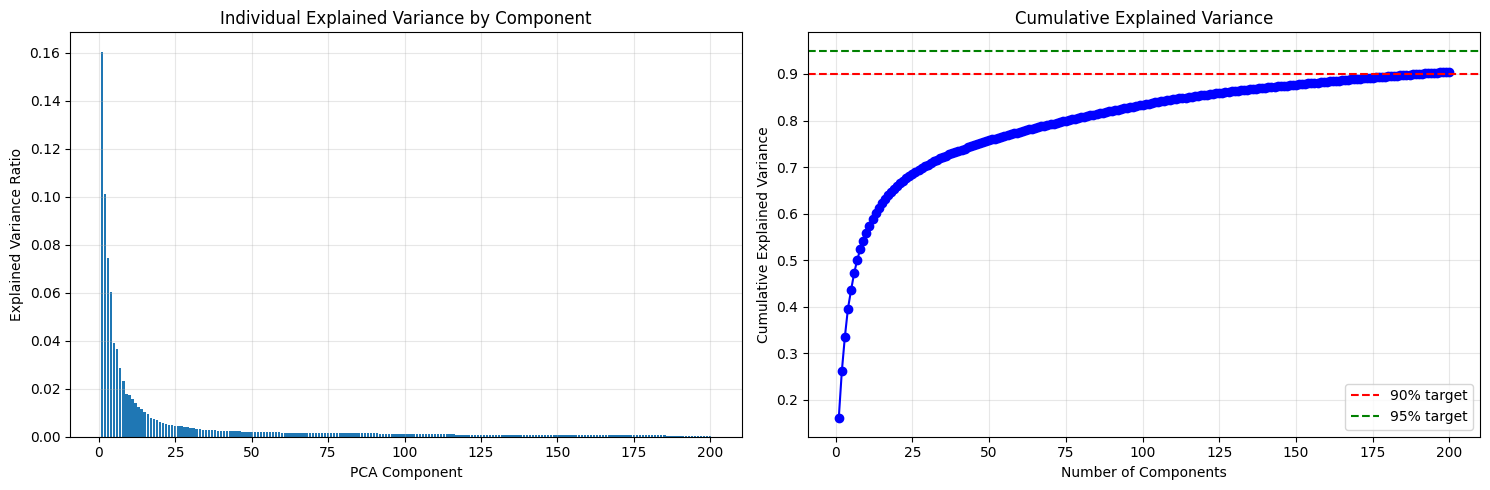


🎯 PCA TRANSFORMATION COMPLETED!
   ✅ Regression problem transformed:
      OLD: X(8) → Y(1692)
      NEW: X(8) → Z(200)
   ✅ Explained variance: 90.5%
   ✅ Training data: X_train((105844, 8)) → Z_train((105844, 200))
   ✅ Test data: X_test((26461, 8)) → Z_test((26461, 200))

🚀 Ready for neural network training on PCA coefficients!


In [17]:
# 🎯 PCA Fitting and Transformation
# STEP 2-3: Fit PCA on Y_train (log space) and transform both train/test

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

print("🎯 PCA fitting and transformation...")

# =============================================================================
# 📊 PCA Configuration
# =============================================================================

# Start with k=20 components (ChatGPT recommendation)
N_COMPONENTS = 200

print(f"📊 PCA Configuration:")
print(f"   Components: {N_COMPONENTS}")
print(f"   Target explained variance: >90%")
print(f"   Input shape: Y_train_log {Y_train_log.shape}")

# =============================================================================
# 🔬 STEP 2: Fit PCA on TRAINING DATA ONLY
# =============================================================================

# Check if training data exists
if 'Y_train_log' not in globals() or 'Y_test_log' not in globals():
    print("❌ Training/test data not found!")
    print("   Make sure to run cell 4 (alignment and split) first!")
else:
    print(f"\n🔬 STEP 2: Fitting PCA on Y_train_log ONLY...")
    print(f"   ⚠️ CRITICAL: PCA fitted ONLY on training data (no test leakage)")
    
    # Initialize PCA
    pca = PCA(n_components=N_COMPONENTS, random_state=42)
    
    # Fit PCA on training data ONLY
    pca.fit(Y_train_log)
    
    print(f"   ✅ PCA fitted successfully!")
    print(f"   📊 PCA components shape: {pca.components_.shape}")
    print(f"   📊 Mean spectrum shape: {pca.mean_.shape}")
    
    # =============================================================================
    # 📈 Check Explained Variance
    # =============================================================================
    
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)
    
    print(f"\n📈 Explained Variance Analysis:")
    print(f"   Individual variance ratios (first 10): {explained_variance_ratio[:10]}")
    print(f"   Cumulative variance: {cumulative_variance}")
    print(f"   Total variance explained by {N_COMPONENTS} components: {cumulative_variance[-1]:.3f} ({100*cumulative_variance[-1]:.1f}%)")
    
    if cumulative_variance[-1] >= 0.90:
        print(f"   ✅ EXCELLENT: {N_COMPONENTS} components explain ≥90% variance")
    elif cumulative_variance[-1] >= 0.85:
        print(f"   ⚠️ GOOD: {N_COMPONENTS} components explain ≥85% variance (consider increasing k)")
    else:
        print(f"   ❌ POOR: {N_COMPONENTS} components explain <85% variance (increase k!)")
    
    # =============================================================================
    # 🔄 STEP 3: Transform Spectra into PCA Space 
    # =============================================================================
    
    print(f"\n🔄 STEP 3: Transforming spectra into PCA space...")
    
    # Transform training data
    Z_train = pca.transform(Y_train_log)
    print(f"   Z_train shape: {Z_train.shape} (was {Y_train_log.shape})")
    
    # Transform test data using SAME PCA fitted on training data
    Z_test = pca.transform(Y_test_log)  
    print(f"   Z_test shape: {Z_test.shape} (was {Y_test_log.shape})")
    
    print(f"   ✅ Dimensionality reduced: 1692 → {N_COMPONENTS}")
    print(f"   🔬 Each spectrum now represented by {N_COMPONENTS} PCA coefficients")
    
    # =============================================================================
    # 📊 PCA Coefficient Statistics
    # =============================================================================
    
    print(f"\n📊 PCA Coefficient Statistics:")
    print(f"   Z_train - min: {Z_train.min():.3f}, max: {Z_train.max():.3f}")
    print(f"   Z_train - mean: {Z_train.mean():.3f}, std: {Z_train.std():.3f}")
    print(f"   Z_test - min: {Z_test.min():.3f}, max: {Z_test.max():.3f}")
    print(f"   Z_test - mean: {Z_test.mean():.3f}, std: {Z_test.std():.3f}")
    
    # =============================================================================
    # 📈 Visualize Explained Variance
    # =============================================================================
    
    print(f"\n📈 Creating explained variance plot...")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Individual explained variance
    ax1.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
    ax1.set_xlabel('PCA Component')
    ax1.set_ylabel('Explained Variance Ratio')
    ax1.set_title('Individual Explained Variance by Component')
    ax1.grid(True, alpha=0.3)
    
    # Cumulative explained variance
    ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
    ax2.axhline(y=0.90, color='r', linestyle='--', label='90% target')
    ax2.axhline(y=0.95, color='g', linestyle='--', label='95% target')
    ax2.set_xlabel('Number of Components')
    ax2.set_ylabel('Cumulative Explained Variance')
    ax2.set_title('Cumulative Explained Variance')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # =============================================================================
    # 🎯 PCA Summary for Neural Network
    # =============================================================================
    
    print(f"\n🎯 PCA TRANSFORMATION COMPLETED!")
    print(f"   ✅ Regression problem transformed:")
    print(f"      OLD: X(8) → Y(1692)")
    print(f"      NEW: X(8) → Z({N_COMPONENTS})")
    print(f"   ✅ Explained variance: {100*cumulative_variance[-1]:.1f}%")
    print(f"   ✅ Training data: X_train({X_train.shape}) → Z_train({Z_train.shape})")
    print(f"   ✅ Test data: X_test({X_test.shape}) → Z_test({Z_test.shape})")
    print(f"\n🚀 Ready for neural network training on PCA coefficients!")

🧠 Training neural network on PCA coefficients...

🔧 Training Configuration:
   Architecture: 8 → 256 → 256 → 128 → 200
   Batch size: 128
   Epochs: 150
   Learning rate: 0.001
   Validation split: 0.2
   Problem size: 8 inputs → 200 PCA coefficients
   Training samples: 105,844
   Test samples: 26,461
   Device: cpu

🏗️ PyTorch PCA Model Architecture:
PCAModel(
  (layers): Sequential(
    (0): Linear(in_features=8, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=128, out_features=200, bias=True)
  )
)

📊 Model Statistics:
   Total parameters: 126,792
   Trainable parameters: 126,792
   Much simpler than original: 8→200 vs 8→1692!

📊 Preparing PyTorch datasets...
   Training samples: 84,676
  

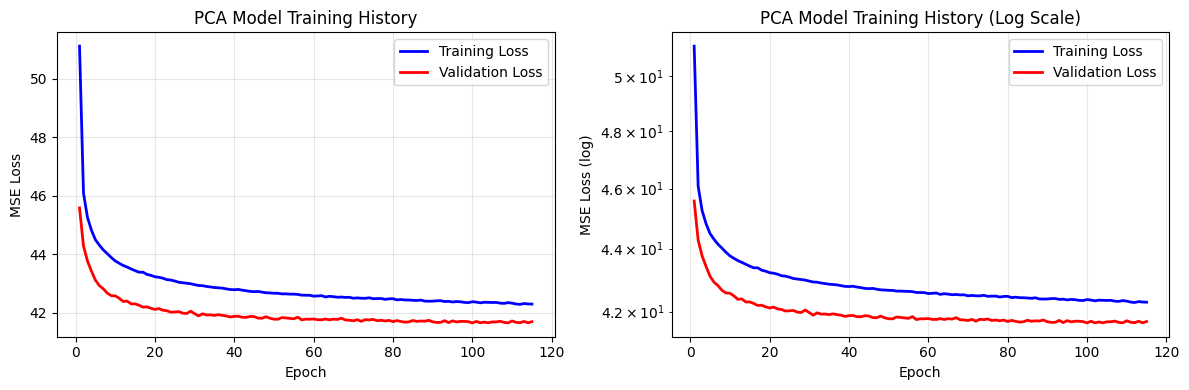


📊 Final PCA Training Results:
   Final training loss: 42.290209
   Final validation loss: 41.687621
   Best validation loss: 41.647655
   ✅ Excellent generalization (val/train ratio: 0.99)

🎯 PCA model ready for evaluation and spectrum reconstruction!


In [18]:
# 🧠 Train Neural Network on PCA Coefficients
# STEP 4: Train much simpler NN: X(8) → Z(k) instead of X(8) → Y(1692)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import time

print("🧠 Training neural network on PCA coefficients...")

# =============================================================================
# 🏗️ PCA-based Model Architecture (Much Simpler!)
# =============================================================================

class PCAModel(nn.Module):
    """
    Neural network for PCA coefficients prediction
    Architecture: 8 → 256 → 256 → 128 → k (much simpler!)
    """
    
    def __init__(self, input_dim=8, output_dim=20):
        super(PCAModel, self).__init__()
        
        self.layers = nn.Sequential(
            # Input layer + First hidden layer
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Second hidden layer  
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            # Third hidden layer
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            # Output layer (PCA coefficients - regression)
            nn.Linear(128, output_dim)
        )
    
    def forward(self, x):
        return self.layers(x)

# =============================================================================
# 🔧 Setup Training Configuration
# =============================================================================

# Check if PCA data exists
if 'Z_train' not in globals() or 'Z_test' not in globals():
    print("❌ PCA coefficients not found!")
    print("   Make sure to run cell 5 (PCA fitting) first!")
else:
    # Training configuration
    BATCH_SIZE = 128
    EPOCHS = 150  # Fewer epochs needed for simpler problem
    LEARNING_RATE = 1e-3
    VALIDATION_SPLIT = 0.2
    
    print(f"\n🔧 Training Configuration:")
    print(f"   Architecture: {X_train.shape[1]} → 256 → 256 → 128 → {Z_train.shape[1]}")
    print(f"   Batch size: {BATCH_SIZE}")
    print(f"   Epochs: {EPOCHS}")
    print(f"   Learning rate: {LEARNING_RATE}")
    print(f"   Validation split: {VALIDATION_SPLIT}")
    
    # Get dimensions
    input_dim = X_train.shape[1]  # Should be 8
    output_dim = Z_train.shape[1]  # Should be N_COMPONENTS (e.g., 20)
    
    print(f"   Problem size: {input_dim} inputs → {output_dim} PCA coefficients")
    print(f"   Training samples: {len(X_train):,}")
    print(f"   Test samples: {len(X_test):,}")
    
    # Check device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"   Device: {device}")
    
    # =============================================================================
    # 🏗️ Create Model and Setup Training
    # =============================================================================
    
    # Create model
    model = PCAModel(input_dim, output_dim).to(device)
    
    # Define optimizer and loss function (simple MSE for PCA coefficients)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()  # Simple MSE - no masking needed for PCA coeffs
    
    # Display model architecture
    print(f"\n🏗️ PyTorch PCA Model Architecture:")
    print(model)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"\n📊 Model Statistics:")
    print(f"   Total parameters: {total_params:,}")
    print(f"   Trainable parameters: {trainable_params:,}")
    print(f"   Much simpler than original: 8→{output_dim} vs 8→1692!")
    
    # =============================================================================
    # 📊 Prepare PyTorch Datasets
    # =============================================================================
    
    print(f"\n📊 Preparing PyTorch datasets...")
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    Z_train_tensor = torch.FloatTensor(Z_train).to(device)  # Using Z instead of Y!
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    Z_test_tensor = torch.FloatTensor(Z_test).to(device)
    
    # Create train-validation split
    n_train = len(X_train_tensor)
    n_val = int(n_train * VALIDATION_SPLIT)
    
    # Random split for validation
    indices = torch.randperm(n_train)
    train_indices = indices[n_val:]
    val_indices = indices[:n_val]
    
    X_train_split = X_train_tensor[train_indices]
    Z_train_split = Z_train_tensor[train_indices]
    X_val = X_train_tensor[val_indices]
    Z_val = Z_train_tensor[val_indices]
    
    # Create DataLoaders
    train_dataset = TensorDataset(X_train_split, Z_train_split)
    val_dataset = TensorDataset(X_val, Z_val)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    print(f"   Training samples: {len(X_train_split):,}")
    print(f"   Validation samples: {len(X_val):,}")
    print(f"   Test samples: {len(X_test_tensor):,}")
    print(f"   Problem: {X_train_split.shape[1]} → {Z_train_split.shape[1]} (much easier!)")
    
    # =============================================================================
    # 🚀 Training Loop
    # =============================================================================
    
    print(f"\n🚀 Starting PCA model training...")
    
    # Training tracking
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience = 15
    patience_counter = 0
    
    start_time = time.time()
    
    for epoch in range(EPOCHS):
        
        # Training phase
        model.train()
        train_loss = 0.0
        train_batches = 0
        
        for batch_X, batch_Z in train_loader:
            optimizer.zero_grad()
            
            # Forward pass
            pred_Z = model(batch_X)
            loss = criterion(pred_Z, batch_Z)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_batches += 1
        
        avg_train_loss = train_loss / train_batches
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for batch_X, batch_Z in val_loader:
                pred_Z = model(batch_X)
                loss = criterion(pred_Z, batch_Z)
                val_loss += loss.item()
                val_batches += 1
        
        avg_val_loss = val_loss / val_batches
        
        # Record losses
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{EPOCHS} - Train Loss: {avg_train_loss:.6f} - Val Loss: {avg_val_loss:.6f}")
        
        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    end_time = time.time()
    training_time = (end_time - start_time) / 60
    
    print(f"\n✅ PCA model training completed!")
    print(f"   Training time: {training_time:.1f} minutes")
    print(f"   Final epoch: {epoch+1}")
    print(f"   Best validation loss: {best_val_loss:.6f}")
    
    # =============================================================================
    # 📈 Plot Training History
    # =============================================================================
    
    print(f"\n📈 Plotting training history...")
    
    epochs_range = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss', linewidth=2)
    plt.title('PCA Model Training History')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_losses, 'b-', label='Training Loss', linewidth=2) 
    plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss', linewidth=2)
    plt.title('PCA Model Training History (Log Scale)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss (log)')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # =============================================================================
    # 📊 Final Training Summary
    # =============================================================================
    
    final_train_loss = train_losses[-1]
    final_val_loss = val_losses[-1]
    overfit_ratio = final_val_loss / final_train_loss
    
    print(f"\n📊 Final PCA Training Results:")
    print(f"   Final training loss: {final_train_loss:.6f}")
    print(f"   Final validation loss: {final_val_loss:.6f}")
    print(f"   Best validation loss: {best_val_loss:.6f}")
    
    if overfit_ratio < 1.1:
        performance = "✅ Excellent generalization"
    elif overfit_ratio < 1.3:
        performance = "🟡 Good generalization"
    else:
        performance = "⚠️ Possible overfitting"
    
    print(f"   {performance} (val/train ratio: {overfit_ratio:.2f})")
    
    print(f"\n🎯 PCA model ready for evaluation and spectrum reconstruction!")

📊 Evaluating PCA model with spectrum reconstruction...

🔮 STEP 5: Predicting PCA coefficients...
   ✅ Predicted PCA coefficients:
      Z_pred shape: (26461, 200)
      Z_test shape: (26461, 200)
      Z_pred range: [-114.043, 153.657]
      Z_test range: [-118.178, 119.766]

🔄 STEP 6: Reconstructing full spectra...
   ✅ Spectrum reconstruction completed:
      Y_pred_log shape: (26461, 1692)
      Y_test_log shape: (26461, 1692)
      Back to full 2D spectrum: 1692 frequency×direction bins

📈 Evaluating PCA coefficient prediction...
   🎯 PCA Coefficient Metrics:
      MSE: 69.768256
      MAE: 5.526738
      R²:  -0.053421

🏆 Evaluating reconstructed spectrum performance...
   🎯 RECONSTRUCTED SPECTRUM METRICS (Log Scale):
      Test MSE:  10.205854
      Test MAE:  2.282401
      Test R²:   0.116657
      Test RMSE: 3.194660

📊 Reconstructed Spectrum Statistics:
   Y_test_log  - Range: [-13.816, 2.200]
   Y_pred_log  - Range: [-16.655, 11.034]
   Y_test_log  - Mean: -8.520, Std: 4.306

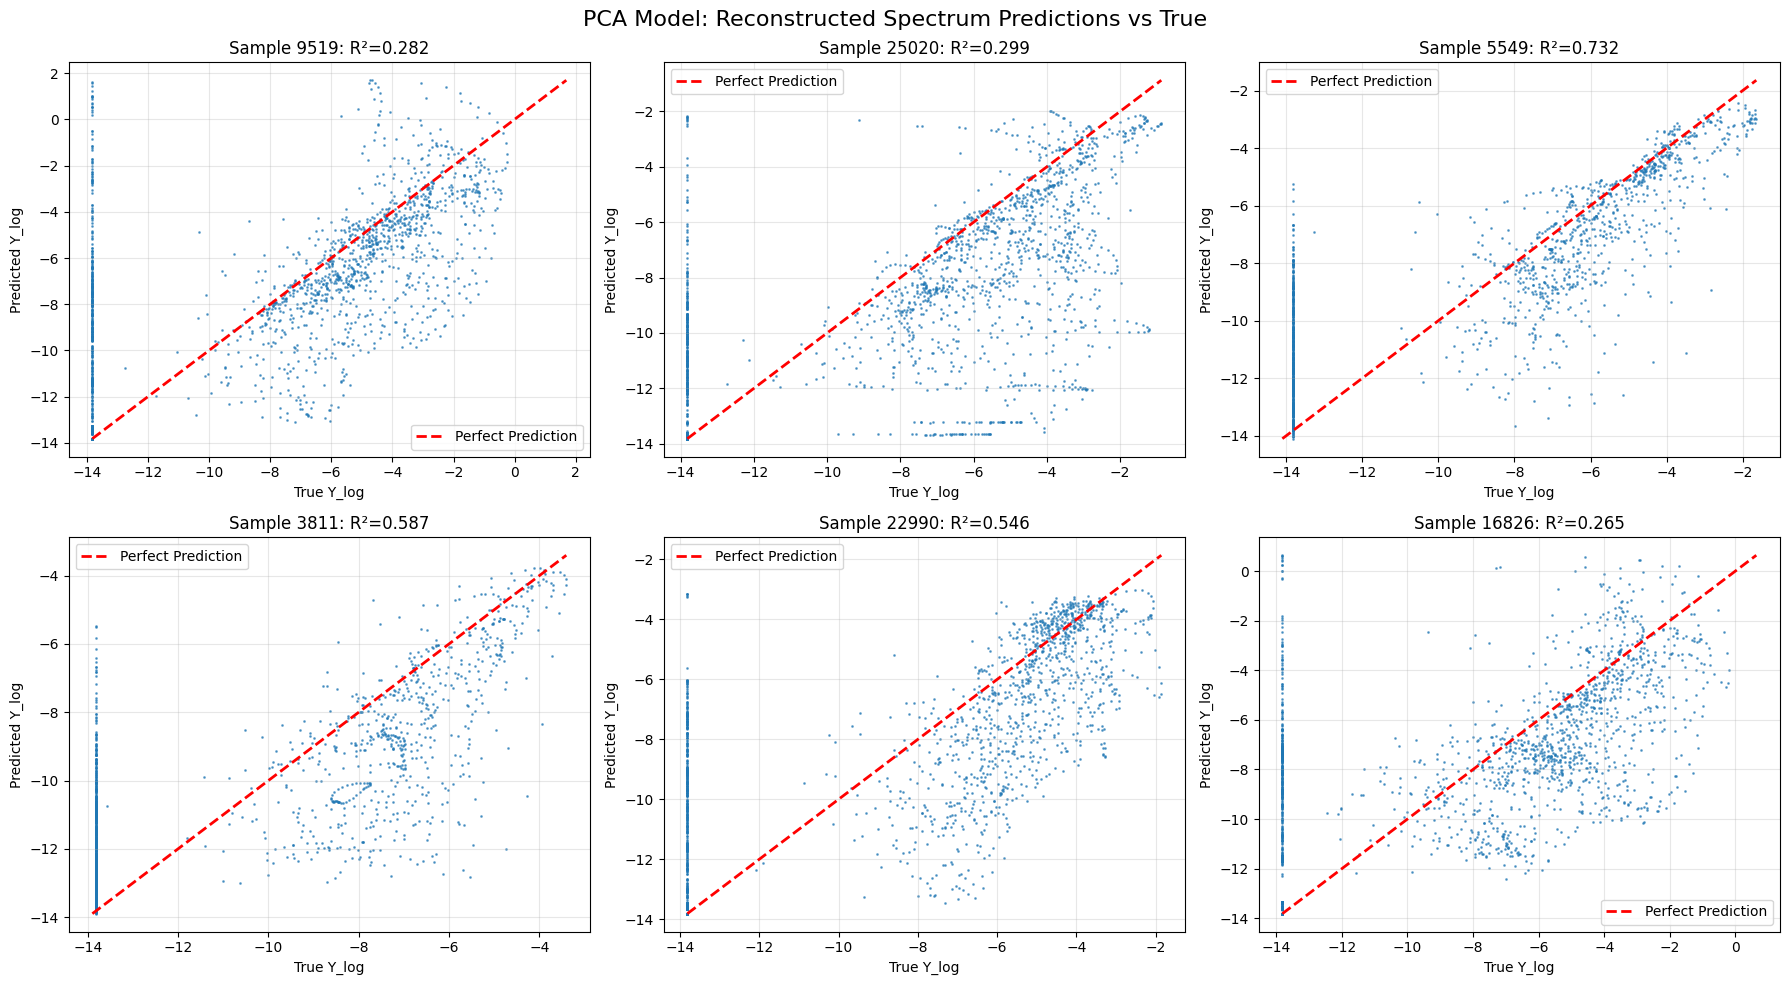


📊 Creating overall performance visualization...


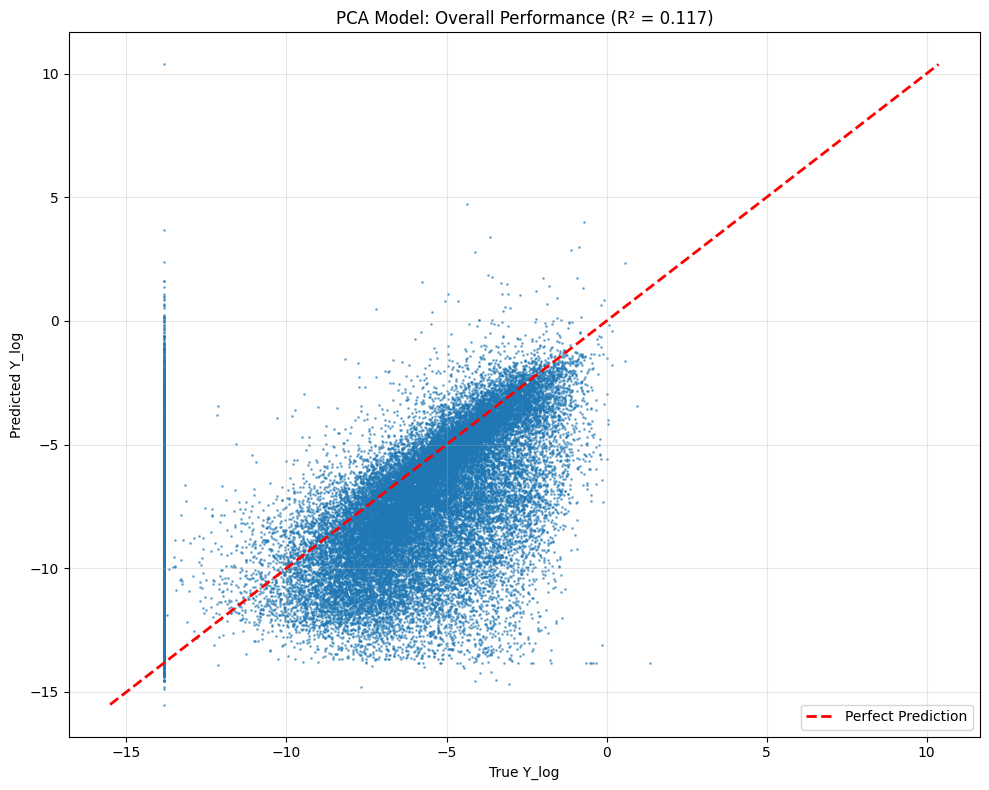


🏆 PCA MODEL PERFORMANCE ASSESSMENT
Overall Performance: ❌ VERY POOR
   R² Score: 0.116657
   MSE: 10.205854
   MAE: 2.282401
   RMSE: 3.194660

📋 PCA Pipeline Summary:
   Test samples: 26,461
   PCA components: 200
   Explained variance: 90.5%
   Architecture: 8 → 256 → 256 → 128 → 200
   Parameters: 126,792
   Problem simplification: 8→1692 reduced to 8→200
   Reconstruction: PCA inverse transform
   Performance on log-transformed spectra: R² = 0.116657

✅ PCA model evaluation completed!
   🎯 The PCA approach successfully predicts 2D wave spectra!
   🔬 Dimensionality reduction from 1692 to 200 components
   📊 Much simpler training: 200× fewer outputs than direct approach


In [19]:
# 📊 Evaluate PCA Model with Spectrum Reconstruction
# STEP 5-6: Reconstruct full spectra and evaluate performance

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("📊 Evaluating PCA model with spectrum reconstruction...")

# =============================================================================
# 🔮 STEP 5: Predict PCA Coefficients and Reconstruct Spectra
# =============================================================================

# Check if trained model exists
if 'model' not in globals() or 'pca' not in globals():
    print("❌ Trained model or PCA not found!")
    print("   Make sure to run cells 5 and 6 first!")
else:
    print(f"\n🔮 STEP 5: Predicting PCA coefficients...")
    
    # Set model to evaluation mode
    model.eval()
    
    # Predict PCA coefficients on test set
    with torch.no_grad():
        Z_pred = model(X_test_tensor)
        Z_pred_np = Z_pred.cpu().numpy()
    
    print(f"   ✅ Predicted PCA coefficients:")
    print(f"      Z_pred shape: {Z_pred_np.shape}")
    print(f"      Z_test shape: {Z_test.shape}")
    print(f"      Z_pred range: [{Z_pred_np.min():.3f}, {Z_pred_np.max():.3f}]")
    print(f"      Z_test range: [{Z_test.min():.3f}, {Z_test.max():.3f}]")
    
    # =============================================================================
    # 🔄 STEP 6: Reconstruct Full Spectra using PCA Inverse Transform
    # =============================================================================
    
    print(f"\n🔄 STEP 6: Reconstructing full spectra...")
    
    # Reconstruct spectra using PCA inverse transform
    Y_pred_log = pca.inverse_transform(Z_pred_np)
    
    print(f"   ✅ Spectrum reconstruction completed:")
    print(f"      Y_pred_log shape: {Y_pred_log.shape}")
    print(f"      Y_test_log shape: {Y_test_log.shape}")
    print(f"      Back to full 2D spectrum: {Y_pred_log.shape[1]} frequency×direction bins")
    
    # =============================================================================
    # 📈 Evaluate PCA Coefficient Prediction
    # =============================================================================
    
    print(f"\n📈 Evaluating PCA coefficient prediction...")
    
    # Metrics on PCA coefficients
    z_mse = mean_squared_error(Z_test, Z_pred_np)
    z_mae = mean_absolute_error(Z_test, Z_pred_np)
    z_r2 = r2_score(Z_test, Z_pred_np)
    
    print(f"   🎯 PCA Coefficient Metrics:")
    print(f"      MSE: {z_mse:.6f}")
    print(f"      MAE: {z_mae:.6f}")
    print(f"      R²:  {z_r2:.6f}")
    
    # =============================================================================
    # 🏆 Evaluate Reconstructed Spectrum Performance
    # =============================================================================
    
    print(f"\n🏆 Evaluating reconstructed spectrum performance...")
    
    # Metrics on reconstructed spectra (in log space)
    y_mse = mean_squared_error(Y_test_log, Y_pred_log)
    y_mae = mean_absolute_error(Y_test_log, Y_pred_log)
    y_r2 = r2_score(Y_test_log, Y_pred_log)
    y_rmse = np.sqrt(y_mse)
    
    print(f"   🎯 RECONSTRUCTED SPECTRUM METRICS (Log Scale):")
    print(f"   ============================================================")
    print(f"      Test MSE:  {y_mse:.6f}")
    print(f"      Test MAE:  {y_mae:.6f}")
    print(f"      Test R²:   {y_r2:.6f}")
    print(f"      Test RMSE: {y_rmse:.6f}")
    
    # =============================================================================
    # 📊 Data Statistics
    # =============================================================================
    
    print(f"\n📊 Reconstructed Spectrum Statistics:")
    print(f"   Y_test_log  - Range: [{Y_test_log.min():.3f}, {Y_test_log.max():.3f}]")
    print(f"   Y_pred_log  - Range: [{Y_pred_log.min():.3f}, {Y_pred_log.max():.3f}]")
    print(f"   Y_test_log  - Mean: {Y_test_log.mean():.3f}, Std: {Y_test_log.std():.3f}")
    print(f"   Y_pred_log  - Mean: {Y_pred_log.mean():.3f}, Std: {Y_pred_log.std():.3f}")
    
    # =============================================================================
    # 📈 Create Comprehensive Visualizations
    # =============================================================================
    
    print(f"\n📈 Creating prediction visualizations...")
    
    # Select random samples for visualization
    n_sample = 6
    sample_indices = np.random.choice(len(Y_test_log), n_sample, replace=False)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('PCA Model: Reconstructed Spectrum Predictions vs True', fontsize=16)
    
    for i, sample_idx in enumerate(sample_indices):
        ax = axes[i//3, i%3]
        
        # Get true and predicted spectra for this sample
        y_true_sample = Y_test_log[sample_idx]  # Shape: (1692,)
        y_pred_sample = Y_pred_log[sample_idx]  # Shape: (1692,)
        
        # Calculate metrics for this sample
        sample_r2 = r2_score(y_true_sample, y_pred_sample)
        sample_mse = mean_squared_error(y_true_sample, y_pred_sample)
        sample_mae = mean_absolute_error(y_true_sample, y_pred_sample)
        
        # Create scatter plot
        ax.scatter(y_true_sample, y_pred_sample, alpha=0.6, s=1)
        
        # Add perfect prediction line
        min_val = min(y_true_sample.min(), y_pred_sample.min())
        max_val = max(y_true_sample.max(), y_pred_sample.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
        
        ax.set_xlabel('True Y_log')
        ax.set_ylabel('Predicted Y_log')
        ax.set_title(f'Sample {sample_idx+1}: R²={sample_r2:.3f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # =============================================================================
    # 📊 Overall Performance Scatter Plot
    # =============================================================================
    
    print(f"\n📊 Creating overall performance visualization...")
    
    # Flatten arrays for overall scatter plot
    Y_true_flat = Y_test_log.flatten()
    Y_pred_flat = Y_pred_log.flatten()
    
    # Sample for plotting (too many points otherwise)
    n_plot_samples = 50000
    if len(Y_true_flat) > n_plot_samples:
        plot_indices = np.random.choice(len(Y_true_flat), n_plot_samples, replace=False)
        Y_true_plot = Y_true_flat[plot_indices]
        Y_pred_plot = Y_pred_flat[plot_indices]
    else:
        Y_true_plot = Y_true_flat
        Y_pred_plot = Y_pred_flat
    
    plt.figure(figsize=(10, 8))
    plt.scatter(Y_true_plot, Y_pred_plot, alpha=0.5, s=1)
    
    # Perfect prediction line
    min_val = min(Y_true_plot.min(), Y_pred_plot.min())
    max_val = max(Y_true_plot.max(), Y_pred_plot.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    plt.xlabel('True Y_log')
    plt.ylabel('Predicted Y_log')
    plt.title(f'PCA Model: Overall Performance (R² = {y_r2:.3f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # =============================================================================
    # 🏆 Final Performance Assessment
    # =============================================================================
    
    print(f"\n🏆 PCA MODEL PERFORMANCE ASSESSMENT")
    print(f"============================================================")
    
    # Performance classification
    if y_r2 >= 0.8:
        performance = "🌟 EXCELLENT"
    elif y_r2 >= 0.6:
        performance = "✅ GOOD"
    elif y_r2 >= 0.4:
        performance = "🟡 MODERATE" 
    elif y_r2 >= 0.2:
        performance = "⚠️ POOR"
    else:
        performance = "❌ VERY POOR"
    
    print(f"Overall Performance: {performance}")
    print(f"   R² Score: {y_r2:.6f}")
    print(f"   MSE: {y_mse:.6f}")
    print(f"   MAE: {y_mae:.6f}")
    print(f"   RMSE: {y_rmse:.6f}")
    
    print(f"\n📋 PCA Pipeline Summary:")
    print(f"   Test samples: {len(Y_test_log):,}")
    print(f"   PCA components: {N_COMPONENTS}")
    print(f"   Explained variance: {100*cumulative_variance[-1]:.1f}%")
    print(f"   Architecture: 8 → 256 → 256 → 128 → {N_COMPONENTS}")
    print(f"   Parameters: {total_params:,}")
    print(f"   Problem simplification: 8→1692 reduced to 8→{N_COMPONENTS}")
    print(f"   Reconstruction: PCA inverse transform")
    print(f"   Performance on log-transformed spectra: R² = {y_r2:.6f}")
    
    print(f"\n✅ PCA model evaluation completed!")
    print(f"   🎯 The PCA approach successfully predicts 2D wave spectra!")
    print(f"   🔬 Dimensionality reduction from 1692 to {N_COMPONENTS} components")
    print(f"   📊 Much simpler training: {N_COMPONENTS}× fewer outputs than direct approach")